Create paths and retrieve data test

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
#test

In [28]:
factors = pd.read_excel("project Factors_2026.xlsx")
stocks = pd.read_excel("project Stocks_2026.xlsx")
funds = pd.read_excel("project Funds_2026.xlsx")

1.)

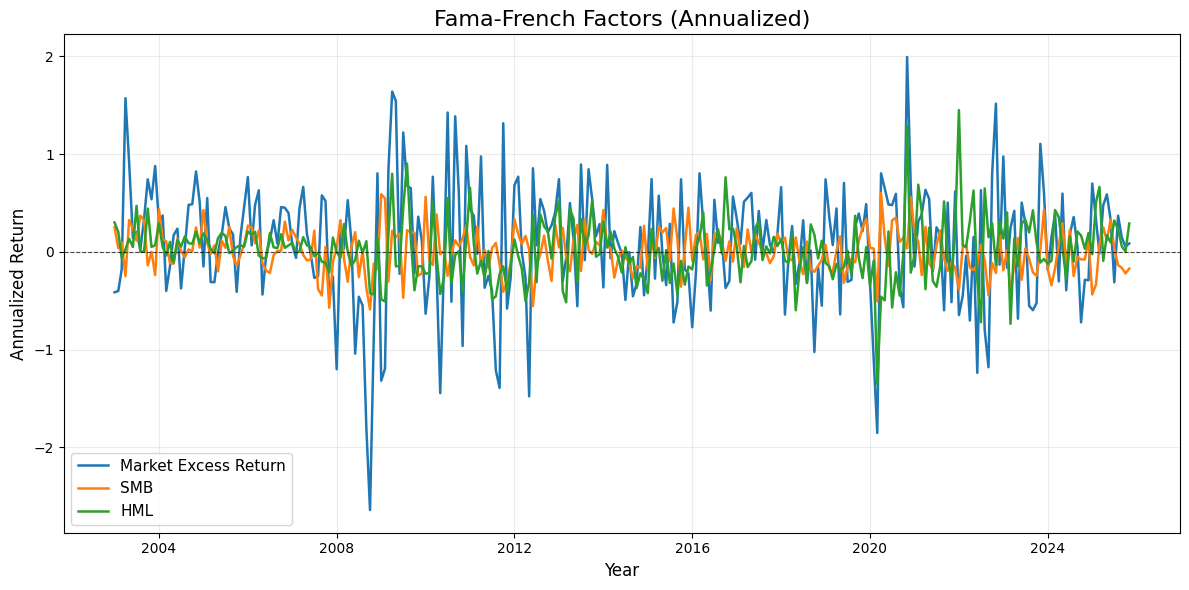

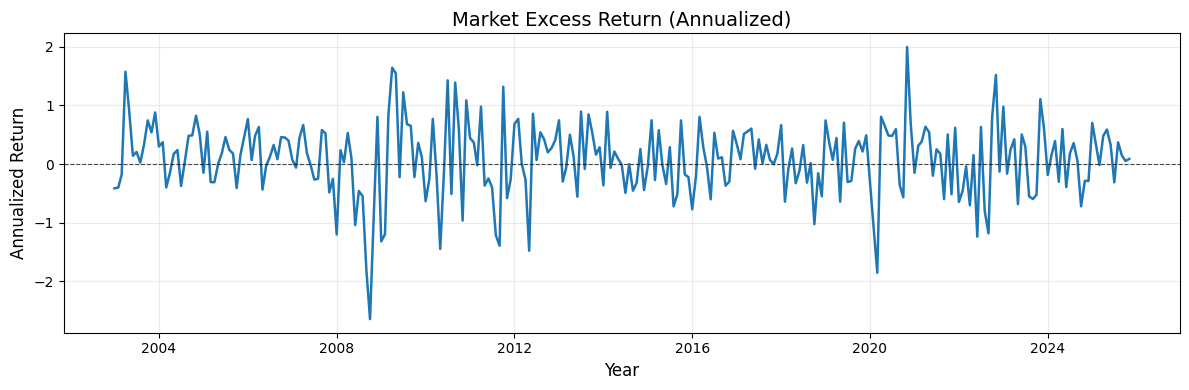

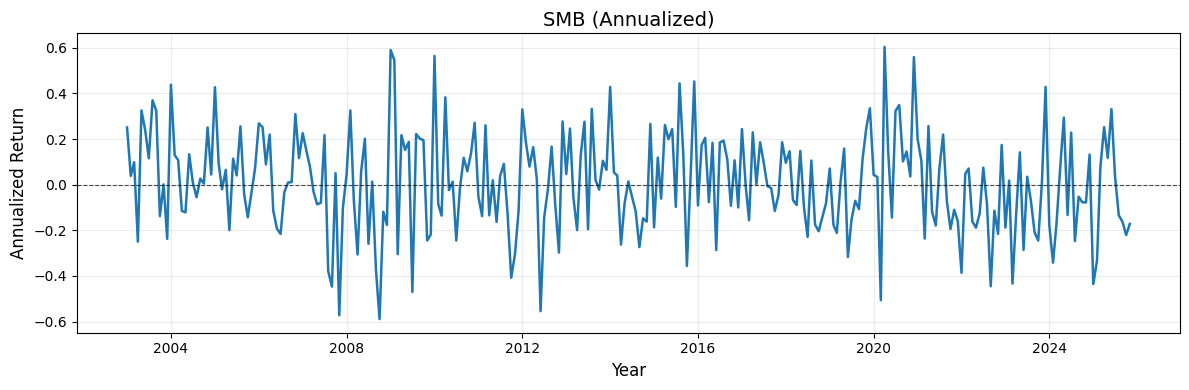

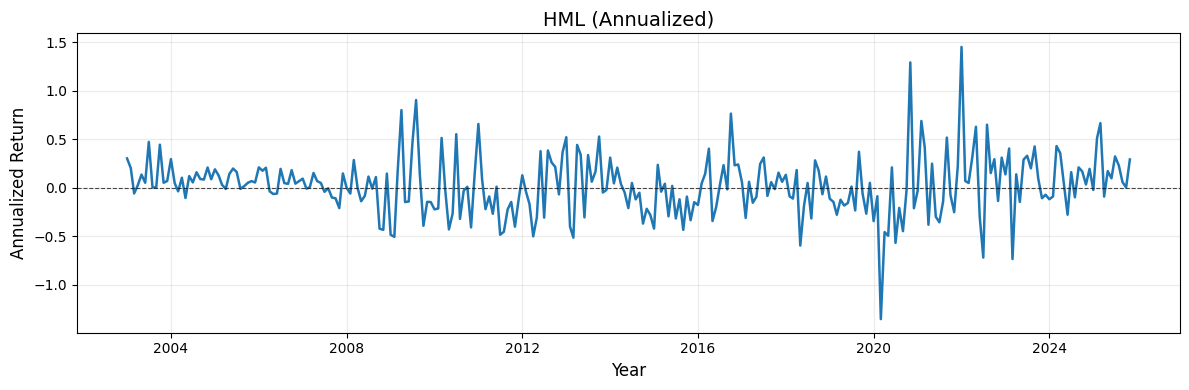

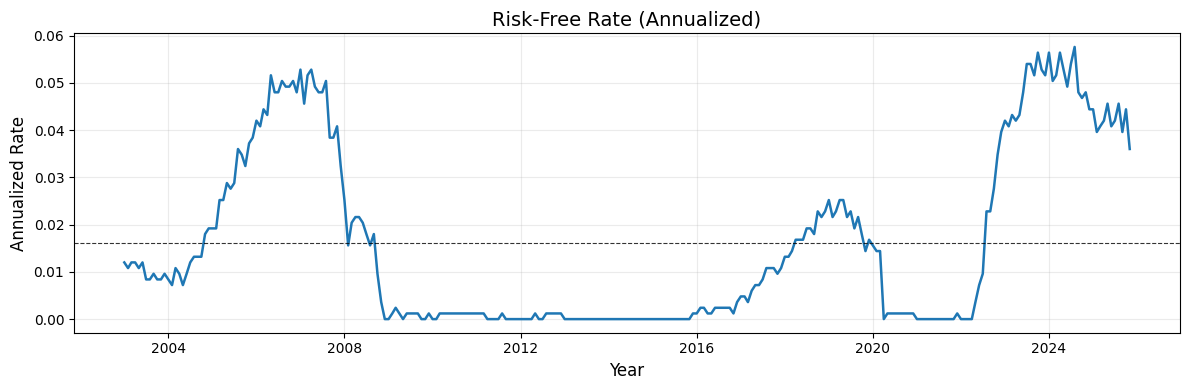

,"Mean (Annual, decimal)","Std Dev (Annual, decimal)"
Rm - Rf,0.0841,0.6200
SMB,0.0087,0.2187
HML,0.0218,0.3071


,"rf_mean (Annual, decimal)"
0,0.0161


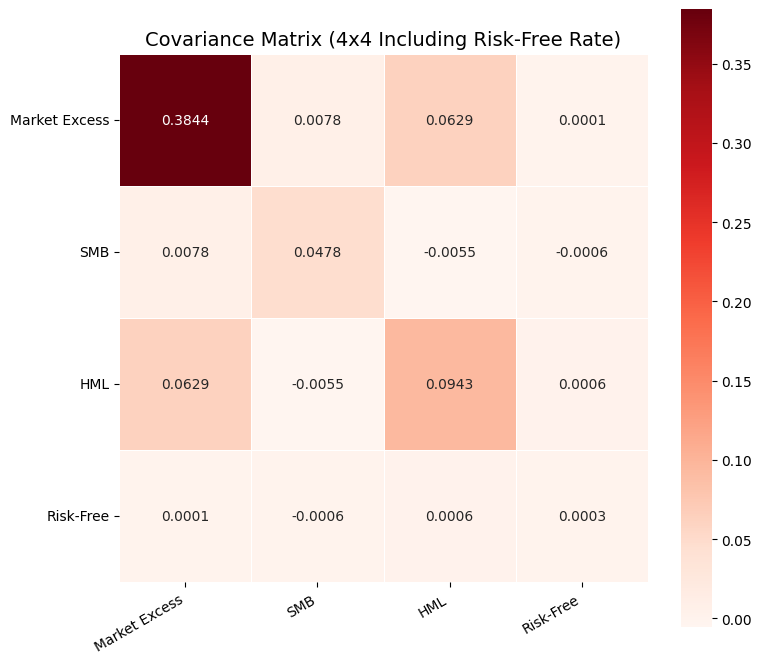

In [51]:
factors_q1 = factors.copy()
stocks_q1 = stocks.copy()

factors_q1[['rm_rf','smb_vw','hml_vw','rf']] *= 12
stocks_q1.iloc[:,3:] *= 12

# Time axis (years)
if {'year','month'}.issubset({c.lower() for c in factors_q1.columns}):
    cols_lower = {c.lower(): c for c in factors_q1.columns}
    year_col = cols_lower['year']
    month_col = cols_lower['month']
    x_dates = pd.to_datetime(
        dict(year=factors_q1[year_col].astype(int), month=factors_q1[month_col].astype(int), day=1)
    )
elif {'Year','Month'}.issubset(set(factors_q1.columns)):
    x_dates = pd.to_datetime(
        dict(year=factors_q1['Year'].astype(int), month=factors_q1['Month'].astype(int), day=1)
    )
else:
    x_dates = factors_q1.index

plt.figure(figsize=(12,6))
plt.plot(x_dates, factors_q1['rm_rf'], label='Market Excess Return', linewidth=1.8)
plt.plot(x_dates, factors_q1['smb_vw'], label='SMB', linewidth=1.8)
plt.plot(x_dates, factors_q1['hml_vw'], label='HML', linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("Fama-French Factors (Annualized)", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(x_dates, factors_q1['rm_rf'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("Market Excess Return (Annualized)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(x_dates, factors_q1['smb_vw'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("SMB (Annualized)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(x_dates, factors_q1['hml_vw'], linewidth=1.8)
plt.axhline(0, color='black', linewidth=0.8, alpha=0.7, linestyle='--')
plt.title("HML (Annualized)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Return", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

rf_mean = factors_q1['rf'].mean()

plt.figure(figsize=(12,4))
plt.plot(x_dates, factors_q1['rf'], linewidth=1.8)
plt.axhline(rf_mean, color='black', linewidth=0.8, alpha=0.8, linestyle='--')
plt.title("Risk-Free Rate (Annualized)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Annualized Rate", fontsize=12)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Mean and annual standard deviation in DECIMAL form
factor_stats = pd.DataFrame({
    "Mean (Annual, decimal)": factors_q1[['rm_rf','smb_vw','hml_vw']].mean(),
    "Std Dev (Annual, decimal)": factors_q1[['rm_rf','smb_vw','hml_vw']].std()
})
factor_stats.index = ["Rm - Rf", "SMB", "HML"]
display(factor_stats.round(4))

display(pd.DataFrame({"rf_mean (Annual, decimal)": [rf_mean]}).round(4))

cov4 = factors_q1[['rm_rf','smb_vw','hml_vw','rf']].cov()

import seaborn as sns

cov4_plot = cov4.copy()
cov4_plot.index = ['Market Excess', 'SMB', 'HML', 'Risk-Free']
cov4_plot.columns = ['Market Excess', 'SMB', 'HML', 'Risk-Free']

plt.figure(figsize=(8,7))
sns.heatmap(
    cov4_plot.round(4),
    annot=True,
    fmt=".4f",
    cmap="Reds",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True,
    annot_kws={"size":10}
)
plt.title("Covariance Matrix (4x4 Including Risk-Free Rate)", fontsize=14)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

2.)

,rf_annual,market_mean_annual,market_std_annual,market_sharpe
0,0.0161,0.1002,0.179,0.47


,Group,N,Avg return (mean of means),Avg std,Median return,Median std
0,Stocks,49,0.2062,0.3329,0.1734,0.3013
1,Funds,10,0.0990,0.1670,0.0953,0.1669


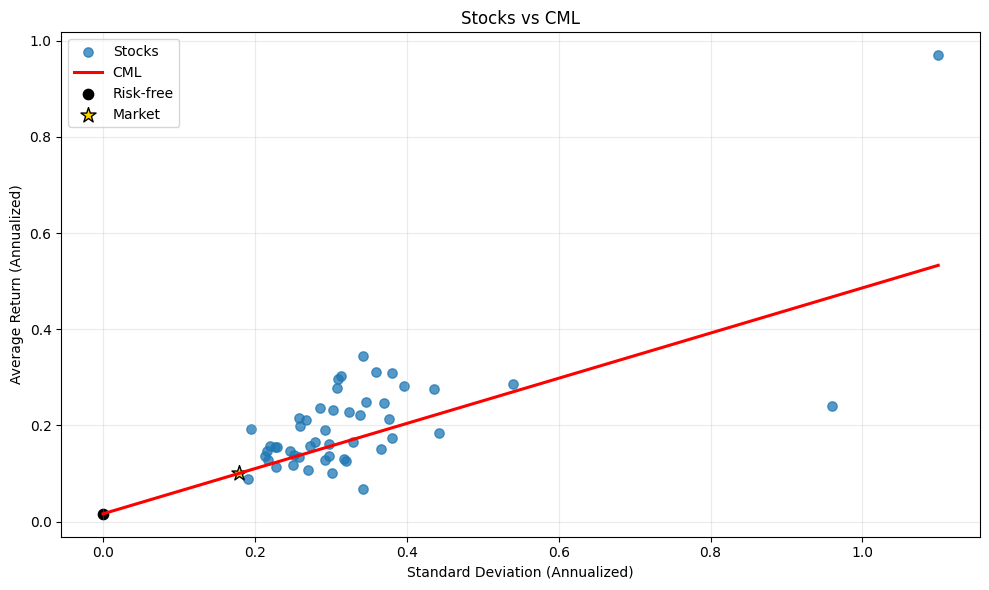

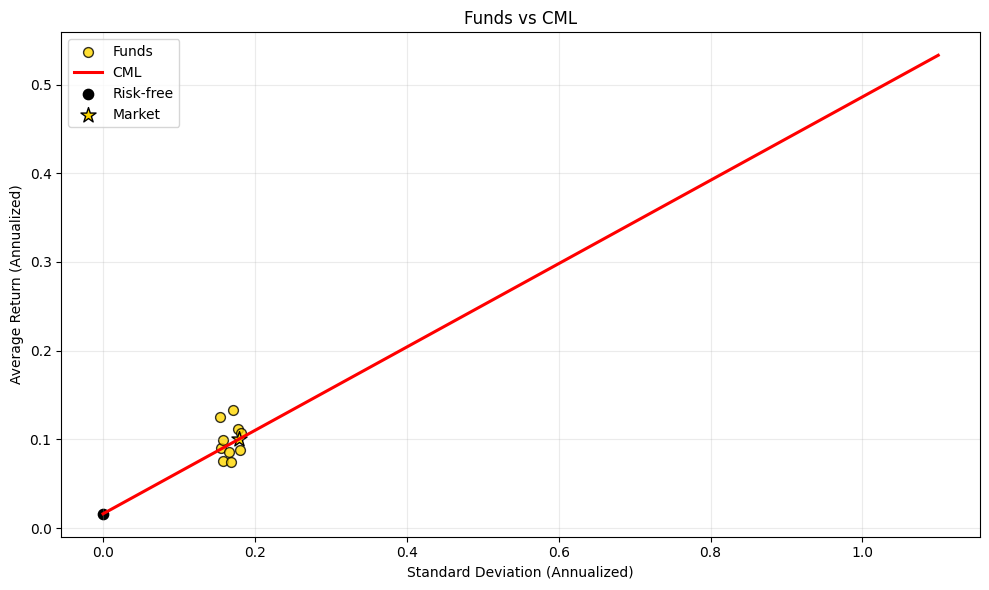

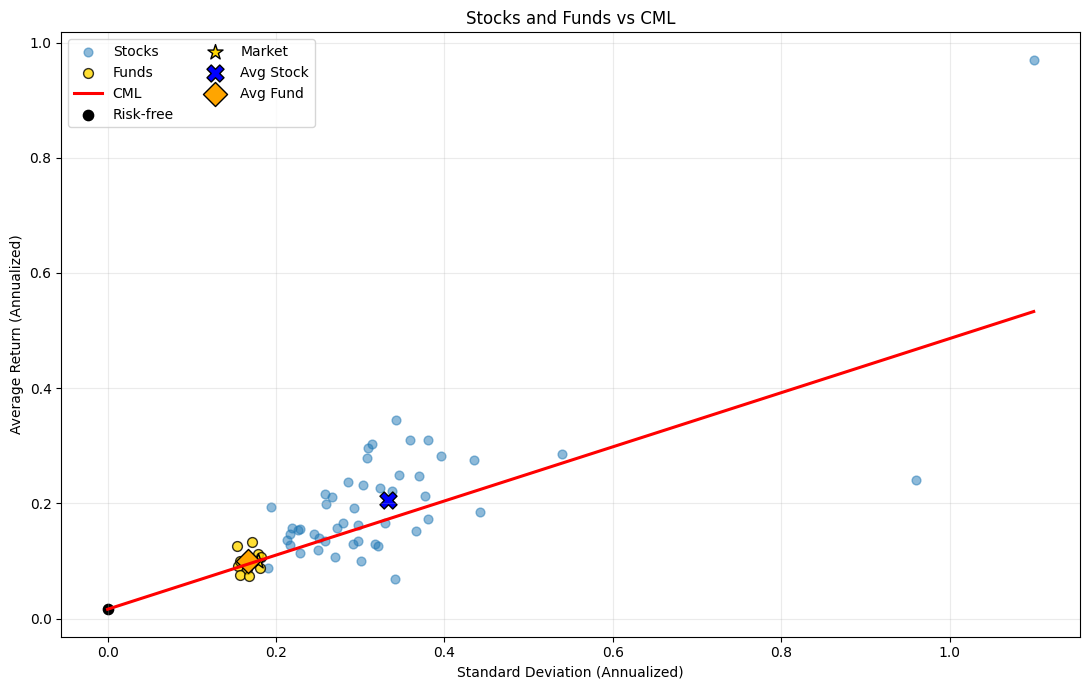

,Group,Above CML,Total
0,Stocks,33,49
1,Funds,6,10


In [47]:
fund_returns = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")

stock_panel = stocks.iloc[:,3:].apply(pd.to_numeric, errors='coerce')
fund_panel = fund_returns.iloc[:,3:].apply(pd.to_numeric, errors='coerce')
factors_num = factors[['rf','rm_rf']].apply(pd.to_numeric, errors='coerce')

# Annualize (from monthly data)
stock_means = stock_panel.mean() * 12
stock_std = stock_panel.std() * np.sqrt(12)

fund_means = fund_panel.mean() * 12
fund_std = fund_panel.std() * np.sqrt(12)

rf = factors_num['rf'].mean() * 12
market_mean = (factors_num['rm_rf'].mean() + factors_num['rf'].mean()) * 12
market_std = factors_num['rm_rf'].std() * np.sqrt(12)

# Sharpe ratio of market (CML slope)
market_sharpe = (market_mean - rf) / market_std

x_max = max(stock_std.max(), fund_std.max())
x = np.linspace(0, x_max, 100)
cml = rf + market_sharpe * x

summary_q2 = pd.DataFrame({
    'Group': ['Stocks', 'Funds'],
    'N': [len(stock_means), len(fund_means)],
    'Avg return (mean of means)': [stock_means.mean(), fund_means.mean()],
    'Avg std': [stock_std.mean(), fund_std.mean()],
    'Median return': [stock_means.median(), fund_means.median()],
    'Median std': [stock_std.median(), fund_std.median()]
})

display(pd.DataFrame({
    "rf_annual": [rf],
    "market_mean_annual": [market_mean],
    "market_std_annual": [market_std],
    "market_sharpe": [market_sharpe]
}).round(4))

display(summary_q2.style.format({
    'Avg return (mean of means)': '{:.4f}',
    'Avg std': '{:.4f}',
    'Median return': '{:.4f}',
    'Median std': '{:.4f}'
}))

plt.figure(figsize=(10,6))
plt.scatter(stock_std, stock_means, alpha=0.75, s=45, label='Stocks')
plt.plot(x, cml, color='red', linewidth=2.2, label='CML')
plt.scatter([0], [rf], color='black', s=55, label='Risk-free')
plt.scatter([market_std], [market_mean], color='gold', edgecolor='black', s=130, marker='*', label='Market')
plt.xlabel("Standard Deviation (Annualized)")
plt.ylabel("Average Return (Annualized)")
plt.title("Stocks vs CML")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.scatter(fund_std, fund_means, alpha=0.80, s=50, color='gold', edgecolor='black', label='Funds')
plt.plot(x, cml, color='red', linewidth=2.2, label='CML')
plt.scatter([0], [rf], color='black', s=55, label='Risk-free')
plt.scatter([market_std], [market_mean], color='gold', edgecolor='black', s=130, marker='*', label='Market')
plt.xlabel("Standard Deviation (Annualized)")
plt.ylabel("Average Return (Annualized)")
plt.title("Funds vs CML")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11,7))
plt.scatter(stock_std, stock_means, alpha=0.50, s=40, label='Stocks')
plt.scatter(fund_std, fund_means, alpha=0.80, s=50, color='gold', edgecolor='black', label='Funds')
plt.plot(x, cml, color='red', linewidth=2.2, label='CML')
plt.scatter([0], [rf], color='black', s=55, label='Risk-free')
plt.scatter([market_std], [market_mean], color='gold', edgecolor='black', s=130, marker='*', label='Market')
plt.scatter([stock_std.mean()], [stock_means.mean()], color='blue', edgecolor='black', s=150, marker='X', label='Avg Stock')
plt.scatter([fund_std.mean()], [fund_means.mean()], color='orange', edgecolor='black', s=150, marker='D', label='Avg Fund')
plt.xlabel("Standard Deviation (Annualized)")
plt.ylabel("Average Return (Annualized)")
plt.title("Stocks and Funds vs CML")
plt.grid(True, alpha=0.25)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

stock_cml_at_sigma = rf + market_sharpe * stock_std
fund_cml_at_sigma = rf + market_sharpe * fund_std

display(pd.DataFrame({
    "Group": ["Stocks", "Funds"],
    "Above CML": [(stock_means > stock_cml_at_sigma).sum(), (fund_means > fund_cml_at_sigma).sum()],
    "Total": [len(stock_means), len(fund_means)]
}))

3.)

,Annual Mean
rf,0.0161
rm_rf,0.0841
smb_vw,0.0087
hml_vw,0.0218


,beta_CAPM,betaM_FF3,betaSMB,betaHML,E[R]_CAPM,E[R]_FF3,Actual_Avg_Return,Diff_FF3_minus_CAPM
Stock,,,,,,,,
Addtech AB B,0.8798,1.0217,0.8542,-0.9693,0.0901,0.0883,0.2973,-0.0018
Alfa Laval AB,0.8057,0.8433,0.2762,-0.2633,0.0839,0.0837,0.2094,-0.0002
Assa Abloy AB B,0.5853,0.6486,-0.3638,-0.3360,0.0653,0.0602,0.1556,-0.0052
Atlas Copco AB A,0.7757,0.8431,-0.0797,-0.3973,0.0813,0.0776,0.2147,-0.0037
Atrium Ljungberg AB,0.7250,0.7245,0.3478,-0.0421,0.0771,0.0791,0.1632,0.0020
Autoliv Inc SEDR,0.8805,0.8780,0.1567,-0.0058,0.0901,0.0912,0.1298,0.0010
Avanza Bank Holding AB,0.7945,0.7866,1.6603,-0.1682,0.0829,0.0930,0.3133,0.0100
Axfood AB,0.2789,0.3847,-0.1077,-0.6264,0.0395,0.0338,0.1537,-0.0057
Bahnhof AB B,0.2158,0.2941,1.2316,-0.5669,0.0342,0.0391,0.3488,0.0049


,Model,MAE
0,CAPM,0.1285
1,FF3,0.1272


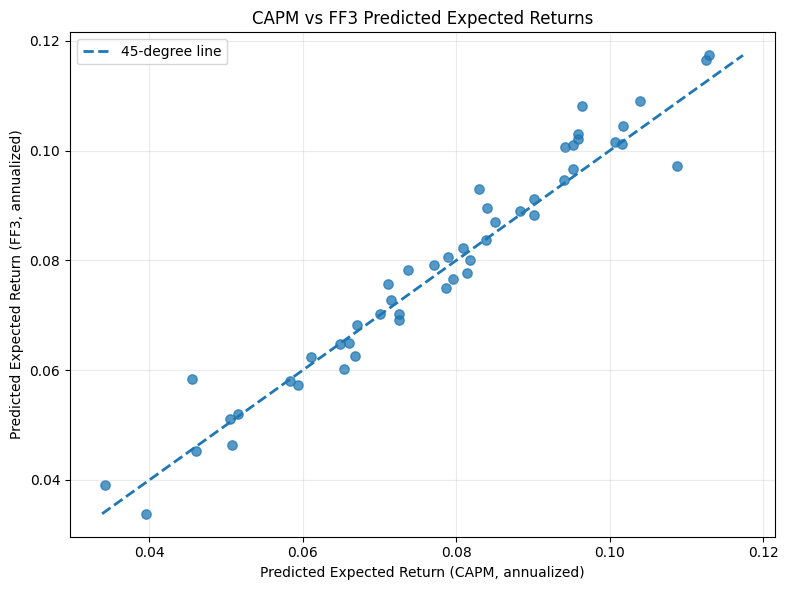

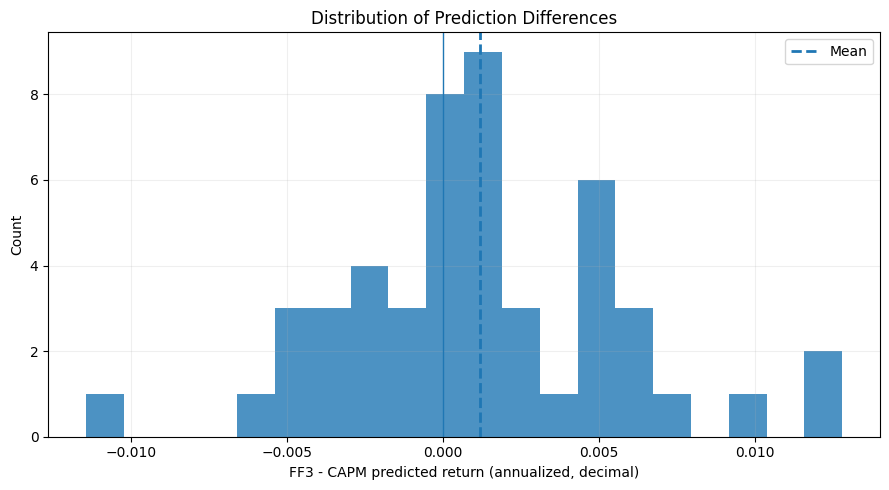

In [55]:
R = stocks.iloc[:,3:].apply(pd.to_numeric, errors="coerce").copy()
R = R * 12

rf = pd.to_numeric(factors["rf"], errors="coerce") * 12
m  = pd.to_numeric(factors["rm_rf"], errors="coerce") * 12
s  = pd.to_numeric(factors["smb_vw"], errors="coerce") * 12
h  = pd.to_numeric(factors["hml_vw"], errors="coerce") * 12

n = min(len(R), len(factors))
R = R.iloc[:n].copy()
rf = rf.iloc[:n].reset_index(drop=True)
m  = m.iloc[:n].reset_index(drop=True)
s  = s.iloc[:n].reset_index(drop=True)
h  = h.iloc[:n].reset_index(drop=True)

mu_rf, mu_m, mu_s, mu_h = rf.mean(), m.mean(), s.mean(), h.mean()

X_capm = sm.add_constant(m.rename("rm_rf"))
X_ff3 = sm.add_constant(pd.DataFrame({"rm_rf": m, "smb_vw": s, "hml_vw": h}))

rows = []
for col in R.columns:
    r_i = pd.to_numeric(R[col], errors="coerce").reset_index(drop=True)
    y = r_i - rf

    capm = sm.OLS(y, X_capm, missing="drop").fit()
    ff3  = sm.OLS(y, X_ff3, missing="drop").fit()

    b_capm = capm.params.get("rm_rf", np.nan)
    b_m3   = ff3.params.get("rm_rf", np.nan)
    b_s3   = ff3.params.get("smb_vw", np.nan)
    b_h3   = ff3.params.get("hml_vw", np.nan)

    er_capm = mu_rf + b_capm * mu_m
    er_ff3  = mu_rf + b_m3 * mu_m + b_s3 * mu_s + b_h3 * mu_h

    rows.append([
        col,
        capm.params.get("const", np.nan), b_capm,
        ff3.params.get("const", np.nan), b_m3, b_s3, b_h3,
        er_capm, er_ff3,
        r_i.mean(),
        capm.rsquared, ff3.rsquared
    ])

results = pd.DataFrame(rows, columns=[
    "Stock","alpha_CAPM","beta_CAPM","alpha_FF3","betaM_FF3","betaSMB","betaHML",
    "E[R]_CAPM","E[R]_FF3","Actual_Avg_Return","R2_CAPM","R2_FF3"
]).set_index("Stock")

results = results.sort_index()

results["Diff_FF3_minus_CAPM"] = results["E[R]_FF3"] - results["E[R]_CAPM"]
results["Error_CAPM"] = results["E[R]_CAPM"] - results["Actual_Avg_Return"]
results["Error_FF3"]  = results["E[R]_FF3"] - results["Actual_Avg_Return"]
results["AbsError_CAPM"] = results["Error_CAPM"].abs()
results["AbsError_FF3"]  = results["Error_FF3"].abs()

display(pd.Series({
    "rf": mu_rf, "rm_rf": mu_m, "smb_vw": mu_s, "hml_vw": mu_h
}).round(4).to_frame("Annual Mean"))

display(
    results[["beta_CAPM","betaM_FF3","betaSMB","betaHML","E[R]_CAPM","E[R]_FF3","Actual_Avg_Return","Diff_FF3_minus_CAPM"]]
    .style.format("{:.4f}")
)

mae_table = pd.DataFrame({
    "Model": ["CAPM", "FF3"],
    "MAE": [results["AbsError_CAPM"].mean(), results["AbsError_FF3"].mean()]
})
display(mae_table.style.format({"MAE": "{:.4f}"}))

plt.figure(figsize=(8,6))
plt.scatter(results["E[R]_CAPM"], results["E[R]_FF3"], alpha=0.75, s=45)
xmin = min(results["E[R]_CAPM"].min(), results["E[R]_FF3"].min())
xmax = max(results["E[R]_CAPM"].max(), results["E[R]_FF3"].max())
plt.plot([xmin, xmax], [xmin, xmax], linestyle="--", linewidth=2, label="45-degree line")
plt.xlabel("Predicted Expected Return (CAPM, annualized)")
plt.ylabel("Predicted Expected Return (FF3, annualized)")
plt.title("CAPM vs FF3 Predicted Expected Returns")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,5))
plt.hist(results["Diff_FF3_minus_CAPM"].dropna(), bins=20, alpha=0.8)
plt.axvline(0, linewidth=1)
plt.axvline(results["Diff_FF3_minus_CAPM"].mean(), linestyle="--", linewidth=2, label="Mean")
plt.xlabel("FF3 - CAPM predicted return (annualized, decimal)")
plt.ylabel("Count")
plt.title("Distribution of Prediction Differences")
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

stock_name_col = stocks.columns[2]
mcap_col_candidates = [c for c in stocks.columns[:3] if c != stock_name_col]
mcap_col = None
for c in mcap_col_candidates:
    if pd.to_numeric(stocks[c], errors="coerce").notna().sum() > 0:
        mcap_col = c
        break

if mcap_col is not None:
    stock_info = pd.DataFrame({
        "Stock": stocks[stock_name_col].astype(str),
        "MarketCap": pd.to_numeric(stocks[mcap_col], errors="coerce")
    }).dropna()

    results_size = results.reset_index()
    results_size["Stock"] = results_size["Stock"].astype(str)
    results_size = results_size.merge(stock_info, on="Stock", how="left").set_index("Stock")

    if results_size["MarketCap"].notna().sum() > 0:
        valid_caps = results_size["MarketCap"].dropna()
        q1 = valid_caps.quantile(1/3)
        q2 = valid_caps.quantile(2/3)

        results_size["SizeGroup"] = pd.cut(
            results_size["MarketCap"],
            bins=[-np.inf, q1, q2, np.inf],
            labels=["Small", "Medium", "Large"]
        )

        size_summary = results_size.groupby("SizeGroup")[[
            "E[R]_CAPM","E[R]_FF3","Actual_Avg_Return","AbsError_CAPM","AbsError_FF3"
        ]].mean().reindex(["Small","Medium","Large"])

        display(size_summary.style.format("{:.4f}"))

        mae_by_size = size_summary[["AbsError_CAPM","AbsError_FF3"]].copy()
        mae_by_size.columns = ["MAE_CAPM", "MAE_FF3"]
        display(mae_by_size.style.format("{:.4f}"))

        plot_df = size_summary[["E[R]_CAPM","E[R]_FF3","Actual_Avg_Return"]].copy()
        plot_df.columns = ["CAPM", "FF3", "Actual"]

        x = np.arange(len(plot_df.index))
        w = 0.25

        plt.figure(figsize=(10,6))
        plt.bar(x - w, plot_df["CAPM"], width=w, label="CAPM", alpha=0.8)
        plt.bar(x,     plot_df["FF3"],  width=w, label="FF3",  alpha=0.8)
        plt.bar(x + w, plot_df["Actual"], width=w, label="Actual", alpha=0.8)

        plt.xticks(x, plot_df.index)
        plt.xlabel("Stock Size Category")
        plt.ylabel("Expected Return (annualized, decimal)")
        plt.title("Expected Returns by Stock Size")
        plt.grid(True, axis="y", alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()

        gap_df = pd.DataFrame({
            "CAPM underprediction gap": plot_df["Actual"] - plot_df["CAPM"],
            "FF3 underprediction gap":  plot_df["Actual"] - plot_df["FF3"]
        }).reindex(["Small", "Medium", "Large"])

        display(gap_df.style.format("{:.4f}"))

        x = np.arange(len(gap_df.index))
        w = 0.35

        plt.figure(figsize=(10,6))
        plt.bar(x - w/2, gap_df["CAPM underprediction gap"], width=w, label="CAPM gap", alpha=0.85)
        plt.bar(x + w/2, gap_df["FF3 underprediction gap"],  width=w, label="FF3 gap", alpha=0.85)

        plt.axhline(0, color="black", linewidth=1)
        plt.xticks(x, gap_df.index)
        plt.xlabel("Stock Size Category")
        plt.ylabel("Underprediction gap (Actual - Predicted)")
        plt.title("Underprediction Gap by Stock Size")
        plt.grid(True, axis="y", alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()

4.)

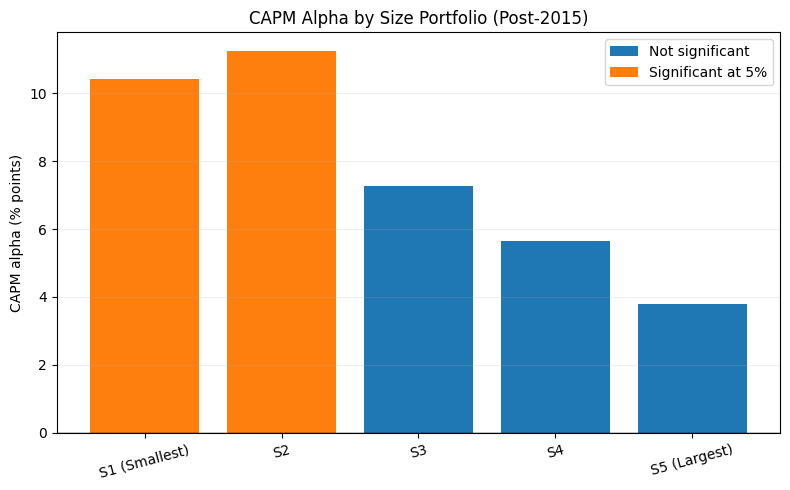

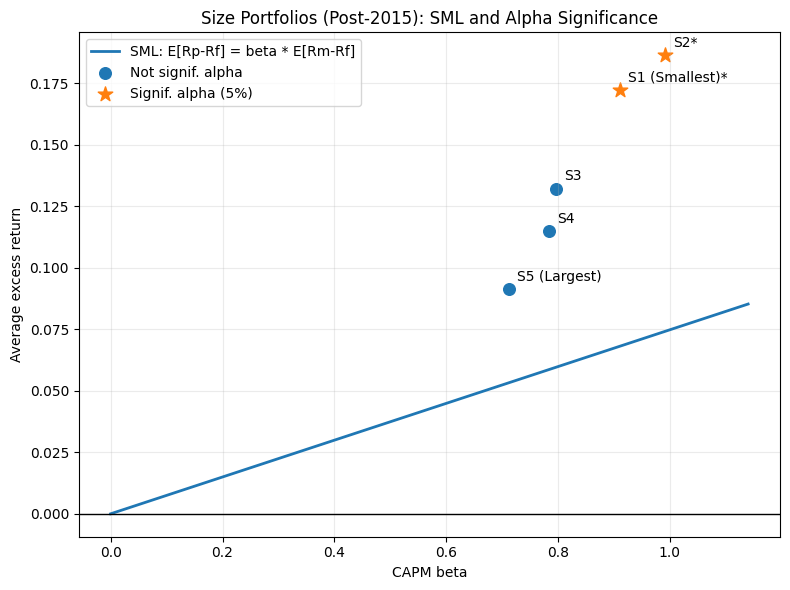

,Mean return,Std dev,alpha_pp,t(alpha),p(alpha),Signif_5%,beta,R2
S1 (Smallest),0.1932,0.1980,10.43,2.48,0.0146,Yes,0.910,0.565
S2,0.2072,0.2278,11.23,2.17,0.0317,Yes,0.991,0.506
S3,0.1530,0.1736,7.26,1.95,0.0532,No,0.796,0.561
S4,0.1357,0.1748,5.64,1.48,0.1426,No,0.784,0.539
S5 (Largest),0.1120,0.1571,3.79,1.12,0.2643,No,0.712,0.552


In [58]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

rets = pd.read_excel("project Stocks_2026.xlsx", sheet_name="return")
mcap = pd.read_excel("project Stocks_2026.xlsx", sheet_name="Market cap")
f = pd.read_excel("project Factors_2026.xlsx")

rets.iloc[:, 3:] = rets.iloc[:, 3:].apply(pd.to_numeric, errors="coerce")
f[["rf", "rm_rf", "smb_vw", "hml_vw"]] = f[["rf", "rm_rf", "smb_vw", "hml_vw"]].apply(pd.to_numeric, errors="coerce")

f = f.rename(columns={"year": "Year", "month": "Month"})
fac = f[["Year", "Month", "rf", "rm_rf"]].copy()

rets = rets[rets["Year"] >= 2016].copy()
mcap = mcap[mcap["Year"] >= 2016].copy()

stock_cols = rets.columns[3:]

rows = []
membership_rows = []

for yr in sorted(rets["Year"].unique()):
    R_y = rets[rets["Year"] == yr].copy()
    C_y = mcap[mcap["Year"] == yr].copy()

    if R_y.empty or C_y.empty:
        continue

    C_jan = C_y[C_y["Month"] == 1]
    cap0_row = C_jan.iloc[0] if not C_jan.empty else C_y.sort_values("Month").iloc[0]

    cap0 = pd.to_numeric(cap0_row[stock_cols], errors="coerce").dropna()
    if len(cap0) < 5:
        continue

    ranks = cap0.rank(method="first")
    groups = pd.qcut(ranks, 5, labels=[1, 2, 3, 4, 5])

    for k in [1, 2, 3, 4, 5]:
        members = list(groups.index[groups == k])
        membership_rows.append({
            "Year": yr,
            "Portfolio": f"S{k}",
            "N_stocks": len(members),
            "Avg_start_cap": cap0.loc[members].mean()
        })

    for _, r in R_y.iterrows():
        for k in [1, 2, 3, 4, 5]:
            members = list(groups.index[groups == k])
            ret_k = pd.to_numeric(r[members], errors="coerce").mean(skipna=True)
            rows.append({
                "Year": int(r["Year"]),
                "Month": int(r["Month"]),
                "Portfolio": f"S{k}",
                "ret": ret_k
            })

ports = pd.DataFrame(rows)
membership = pd.DataFrame(membership_rows)

portfolio_labels = {
    "S1": "S1 (Smallest)",
    "S2": "S2",
    "S3": "S3",
    "S4": "S4",
    "S5": "S5 (Largest)"
}

ports = ports.merge(fac, on=["Year", "Month"], how="inner")
ports["excess"] = ports["ret"] - ports["rf"]

stats4_monthly = ports.groupby("Portfolio")["ret"].agg(["mean", "std", "min", "max", "count"]).reindex(["S1", "S2", "S3", "S4", "S5"])

stats4 = pd.DataFrame(index=stats4_monthly.index)
stats4["Mean return"] = stats4_monthly["mean"] * 12
stats4["Std dev"] = stats4_monthly["std"] * np.sqrt(12)
stats4["Min"] = stats4_monthly["min"] * 12
stats4["Max"] = stats4_monthly["max"] * 12
stats4["N months"] = stats4_monthly["count"]

alpha_rows = []
for p in ["S1", "S2", "S3", "S4", "S5"]:
    dfp = ports[ports["Portfolio"] == p].dropna(subset=["excess", "rm_rf"]).copy()
    fit = sm.OLS(dfp["excess"], sm.add_constant(dfp["rm_rf"])).fit()

    alpha_monthly = fit.params.get("const", np.nan)
    alpha_rows.append({
        "Portfolio": p,
        "alpha": alpha_monthly * 12,
        "alpha_pp": alpha_monthly * 12 * 100,
        "t(alpha)": fit.tvalues.get("const", np.nan),
        "p(alpha)": fit.pvalues.get("const", np.nan),
        "Signif_5%": "Yes" if fit.pvalues.get("const", np.nan) < 0.05 else "No",
        "beta": fit.params.get("rm_rf", np.nan),
        "R2": fit.rsquared,
        "N": int(fit.nobs)
    })

alpha4 = pd.DataFrame(alpha_rows).set_index("Portfolio").reindex(["S1", "S2", "S3", "S4", "S5"])

plt.figure(figsize=(8, 5))
sig = alpha4["p(alpha)"] < 0.05
x_pos = np.arange(len(alpha4.index))

plt.bar(x_pos[~sig.values], alpha4.loc[~sig, "alpha_pp"], label="Not significant")
plt.bar(x_pos[sig.values], alpha4.loc[sig, "alpha_pp"], label="Significant at 5%")
plt.axhline(0, linewidth=1, color="black")
plt.xticks(x_pos, [portfolio_labels.get(i, i) for i in alpha4.index], rotation=15)
plt.ylabel("CAPM alpha (% points)")
plt.title("CAPM Alpha by Size Portfolio (Post-2015)")
plt.grid(True, axis="y", alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

reg_plot = ports.groupby("Portfolio")["excess"].mean().to_frame("mean_excess").join(alpha4[["beta", "p(alpha)"]]).reindex(["S1", "S2", "S3", "S4", "S5"])
reg_plot["mean_excess"] = reg_plot["mean_excess"] * 12
mu_mkt = ports["rm_rf"].mean() * 12

x = np.linspace(0, max(reg_plot["beta"].max() * 1.15, 0.1), 100)
sml = mu_mkt * x

plt.figure(figsize=(8, 6))
plt.plot(x, sml, linewidth=2, label="SML: E[Rp-Rf] = beta * E[Rm-Rf]")

sig = reg_plot["p(alpha)"] < 0.05
plt.scatter(reg_plot.loc[~sig, "beta"], reg_plot.loc[~sig, "mean_excess"], s=70, label="Not signif. alpha")
plt.scatter(reg_plot.loc[sig, "beta"], reg_plot.loc[sig, "mean_excess"], s=120, marker="*", label="Signif. alpha (5%)")

for idx, row in reg_plot.iterrows():
    star = "*" if row["p(alpha)"] < 0.05 else ""
    label = portfolio_labels.get(idx, idx) + star
    plt.annotate(label, (row["beta"], row["mean_excess"]), textcoords="offset points", xytext=(6, 6))

plt.axhline(0, linewidth=1, color="black")
plt.xlabel("CAPM beta")
plt.ylabel("Average excess return")
plt.title("Size Portfolios (Post-2015): SML and Alpha Significance")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

output4 = stats4[["Mean return", "Std dev"]].join(alpha4[["alpha_pp", "t(alpha)", "p(alpha)", "Signif_5%", "beta", "R2"]]).reindex(["S1", "S2", "S3", "S4", "S5"])
output4_show = output4.copy()
output4_show.index = [portfolio_labels.get(i, i) for i in output4_show.index]

display(output4_show.style.format({
    "Mean return": "{:.4f}",
    "Std dev": "{:.4f}",
    "alpha_pp": "{:.2f}",
    "t(alpha)": "{:.2f}",
    "p(alpha)": "{:.4f}",
    "beta": "{:.3f}",
    "R2": "{:.3f}"
}))

5.)

,fund type,net_alpha,gross_alpha,gap_gross_minus_net,net_alpha_pct,gross_alpha_pct,gap_gross_minus_net_pct,net_t_alpha,net_p_alpha,net_signif_5%,net_beta,net_R2,net_N,gross_t_alpha,gross_p_alpha,gross_signif_5%,gross_beta,gross_R2,gross_N
Fund,,,,,,,,,,,,,,,,,,,
Swedbank Robur Exportfond A,actively managed equity fund,0.0731,0.0850,0.0119,7.31,8.50,1.19,2.49,0.0135,Yes,0.584,0.370,264,2.88,0.0042,Yes,0.585,0.369,264
Aktiespararna Topp Sverige Hållbar A,passively managed equity fund,0.0636,0.0698,0.0061,6.36,6.98,0.61,2.65,0.0086,Yes,0.591,0.473,264,2.90,0.0040,Yes,0.591,0.472,264
Swedbank Robur Småbolagsfond Sverige A,actively managed equity fund,0.0470,0.0577,0.0107,4.70,5.77,1.07,1.62,0.1073,No,0.652,0.427,264,1.98,0.0489,Yes,0.653,0.426,264
Öhman Sweden Micro Cap A,actively managed equity fund,0.0422,0.0468,0.0045,4.22,4.68,0.45,1.44,0.1514,No,0.679,0.451,258,1.59,0.1129,No,0.679,0.451,258
SEB Sweden Equity C,actively managed equity fund,0.0373,0.0405,0.0032,3.73,4.05,0.32,1.52,0.1293,No,0.611,0.480,264,1.65,0.0998,No,0.611,0.479,264
Storebrand Sverige A SEK,index-based equity fund,0.0298,0.0314,0.0016,2.98,3.14,0.16,1.22,0.2253,No,0.590,0.462,264,1.28,0.2014,No,0.590,0.462,264
Swedbank Robur Sverige A,actively managed equity fund,0.0214,0.0321,0.0107,2.14,3.21,1.07,0.74,0.4616,No,0.670,0.440,264,1.10,0.2714,No,0.670,0.439,264
Enter Sverige Hållbar Tillväxt A,actively managed equity fund,0.0202,0.0309,0.0107,2.02,3.09,1.07,0.81,0.4195,No,0.661,0.510,264,1.23,0.2185,No,0.662,0.509,264
AMF Aktiefond Sverige,actively managed equity fund,0.0148,0.0172,0.0024,1.48,1.72,0.24,0.59,0.5555,No,0.593,0.453,264,0.69,0.4934,No,0.593,0.452,264


,n_funds,avg_net_alpha_pct,avg_gross_alpha_pct,avg_gap_pct,median_net_alpha_pct,median_gross_alpha_pct,median_gap_pct,positive_net_alpha_share,positive_gross_alpha_share,net_signif_5_share,gross_signif_5_share
Group,,,,,,,,,,,
All funds,10,3.61,4.33,0.73,3.35,3.63,0.84,100%,100%,20%,30%
actively managed equity fund,8,3.34,4.15,0.81,2.94,3.63,1.07,100%,100%,12%,25%
index-based equity fund,1,2.98,3.14,0.16,2.98,3.14,0.16,100%,100%,0%,0%
passively managed equity fund,1,6.36,6.98,0.61,6.36,6.98,0.61,100%,100%,100%,100%


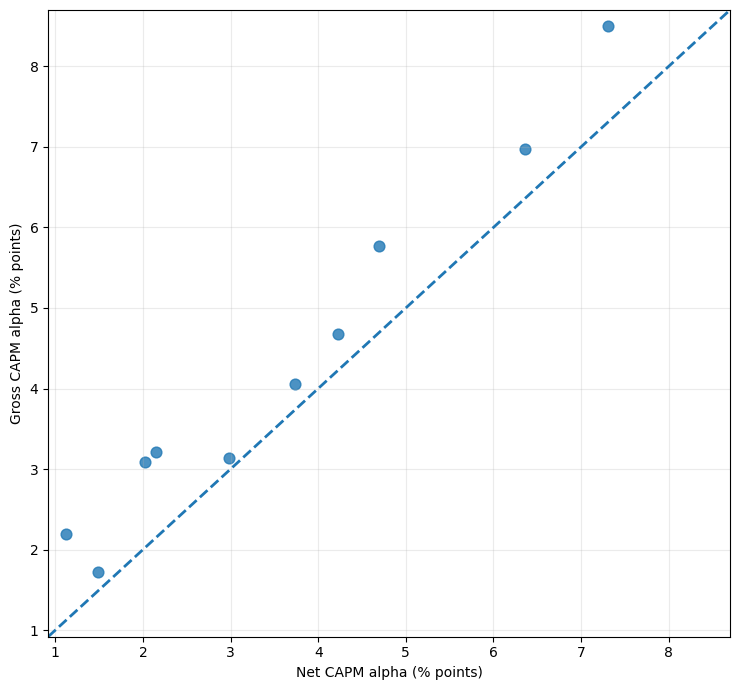

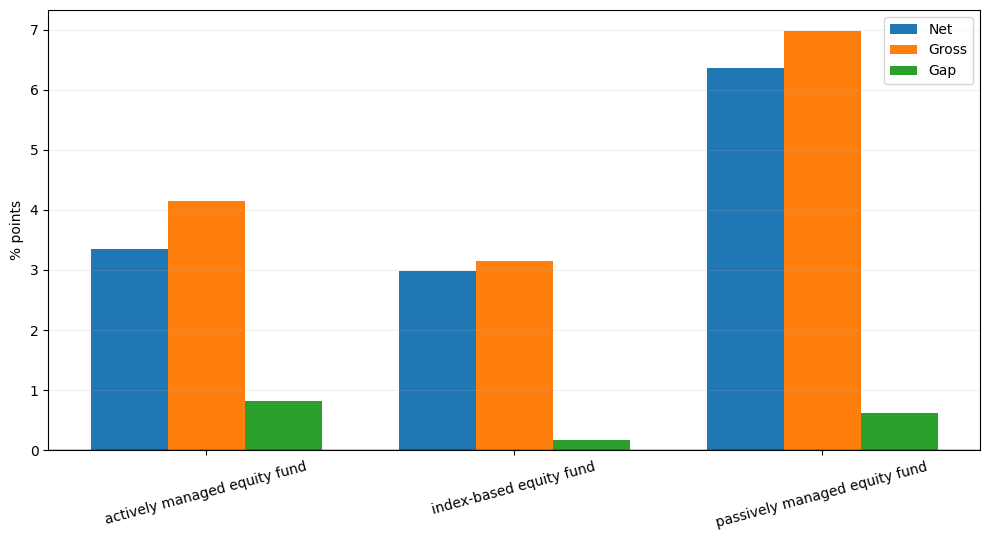

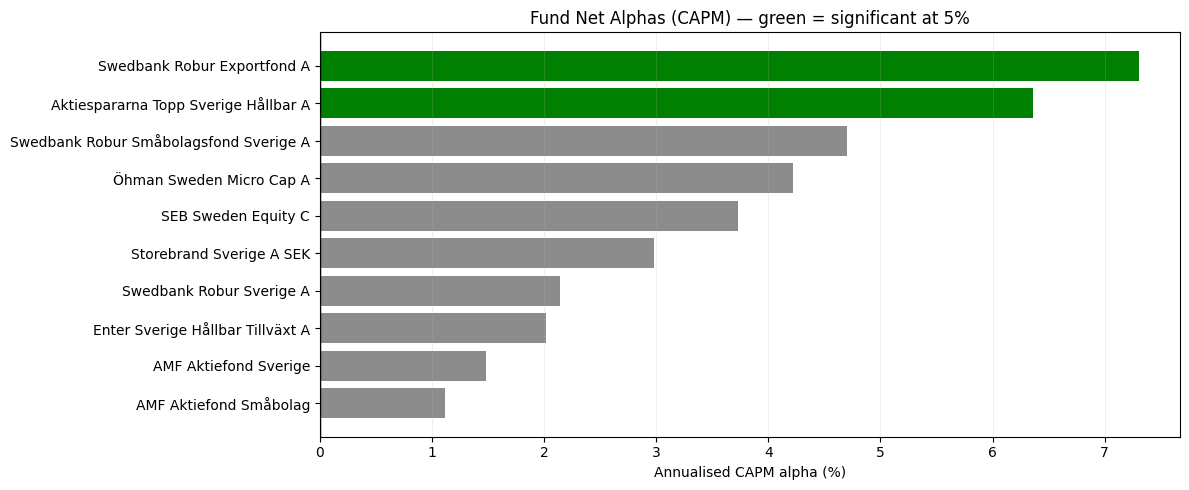

In [59]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

fund_net   = pd.read_excel("project Funds_2026.xlsx", sheet_name="Net")
fund_gross = pd.read_excel("project Funds_2026.xlsx", sheet_name="Gross")
info       = pd.read_excel("project Funds_2026.xlsx", sheet_name="Info")
f          = pd.read_excel("project Factors_2026.xlsx")

f[["rf","rm_rf","smb_vw","hml_vw"]] *= 12
fund_net.iloc[:,3:]   *= 12
fund_gross.iloc[:,3:] *= 12

f = f.rename(columns={"year":"Year","month":"Month"})
fac = f[["Year","Month","rf","rm_rf"]].copy()

net   = fund_net.merge(fac, on=["Year","Month"], how="inner")
gross = fund_gross.merge(fac, on=["Year","Month"], how="inner")

fund_cols = fund_net.columns[3:]

def capm_alpha_table(df, cols):
    rows = []
    X_all = sm.add_constant(pd.to_numeric(df["rm_rf"], errors="coerce"))
    rf_ser = pd.to_numeric(df["rf"], errors="coerce")

    for c in cols:
        y = pd.to_numeric(df[c], errors="coerce") - rf_ser
        fit = sm.OLS(y, X_all, missing="drop").fit()

        rows.append({
            "Fund": c,
            "alpha": fit.params.get("const", np.nan),
            "alpha_pct": 100 * fit.params.get("const", np.nan),
            "t_alpha": fit.tvalues.get("const", np.nan),
            "p_alpha": fit.pvalues.get("const", np.nan),
            "signif_5%": "Yes" if fit.pvalues.get("const", np.nan) < 0.05 else "No",
            "beta": fit.params.get("rm_rf", np.nan),
            "R2": fit.rsquared,
            "N": int(fit.nobs)
        })
    return pd.DataFrame(rows).set_index("Fund")

alpha_net   = capm_alpha_table(net, fund_cols).add_prefix("net_")
alpha_gross = capm_alpha_table(gross, fund_cols).add_prefix("gross_")

results = pd.concat([alpha_net, alpha_gross], axis=1)
results["gap_gross_minus_net"] = results["gross_alpha"] - results["net_alpha"]
results["gap_gross_minus_net_pct"] = 100 * results["gap_gross_minus_net"]

info_cols_lower = {c.lower(): c for c in info.columns}
name_col = next((info_cols_lower[c] for c in ["fund name", "fund_name", "name"] if c in info_cols_lower), None)
type_col = next((info_cols_lower[c] for c in ["fund type", "fund_type", "type"] if c in info_cols_lower), None)

if name_col is not None:
    add_cols = [name_col] + ([type_col] if type_col is not None else [])
    info_map = info[add_cols].copy().drop_duplicates(subset=[name_col]).set_index(name_col)
    results = results.join(info_map, how="left")

if type_col is not None and type_col in results.columns:
    results[type_col] = results[type_col].astype(str).str.strip()

# ---------- ONE MAIN TABLE (all essential fund-level data) ----------
main_cols = [
    "net_alpha", "gross_alpha", "gap_gross_minus_net",
    "net_alpha_pct", "gross_alpha_pct", "gap_gross_minus_net_pct",
    "net_t_alpha", "net_p_alpha", "net_signif_5%", "net_beta", "net_R2", "net_N",
    "gross_t_alpha", "gross_p_alpha", "gross_signif_5%", "gross_beta", "gross_R2", "gross_N"
]
main_cols = [c for c in main_cols if c in results.columns]
if type_col is not None and type_col in results.columns:
    main_cols = [type_col] + main_cols

main_table = results[main_cols].sort_values("net_alpha", ascending=False)

display(
    main_table.style.format({
        "net_alpha": "{:.4f}",
        "gross_alpha": "{:.4f}",
        "gap_gross_minus_net": "{:.4f}",
        "net_alpha_pct": "{:.2f}",
        "gross_alpha_pct": "{:.2f}",
        "gap_gross_minus_net_pct": "{:.2f}",
        "net_t_alpha": "{:.2f}",
        "gross_t_alpha": "{:.2f}",
        "net_p_alpha": "{:.4f}",
        "gross_p_alpha": "{:.4f}",
        "net_beta": "{:.3f}",
        "gross_beta": "{:.3f}",
        "net_R2": "{:.3f}",
        "gross_R2": "{:.3f}"
    })
)

# ---------- ONE SUMMARY TABLE ----------
summary_rows = [{
    "Group": "All funds",
    "n_funds": len(results),
    "avg_net_alpha_pct": 100 * results["net_alpha"].mean(),
    "avg_gross_alpha_pct": 100 * results["gross_alpha"].mean(),
    "avg_gap_pct": 100 * results["gap_gross_minus_net"].mean(),
    "median_net_alpha_pct": 100 * results["net_alpha"].median(),
    "median_gross_alpha_pct": 100 * results["gross_alpha"].median(),
    "median_gap_pct": 100 * results["gap_gross_minus_net"].median(),
    "positive_net_alpha_share": (results["net_alpha"] > 0).mean(),
    "positive_gross_alpha_share": (results["gross_alpha"] > 0).mean(),
    "net_signif_5_share": (results["net_p_alpha"] < 0.05).mean(),
    "gross_signif_5_share": (results["gross_p_alpha"] < 0.05).mean()
}]

if type_col is not None and type_col in results.columns:
    for g, d in results.groupby(type_col):
        summary_rows.append({
            "Group": str(g),
            "n_funds": len(d),
            "avg_net_alpha_pct": 100 * d["net_alpha"].mean(),
            "avg_gross_alpha_pct": 100 * d["gross_alpha"].mean(),
            "avg_gap_pct": 100 * d["gap_gross_minus_net"].mean(),
            "median_net_alpha_pct": 100 * d["net_alpha"].median(),
            "median_gross_alpha_pct": 100 * d["gross_alpha"].median(),
            "median_gap_pct": 100 * d["gap_gross_minus_net"].median(),
            "positive_net_alpha_share": (d["net_alpha"] > 0).mean(),
            "positive_gross_alpha_share": (d["gross_alpha"] > 0).mean(),
            "net_signif_5_share": (d["net_p_alpha"] < 0.05).mean(),
            "gross_signif_5_share": (d["gross_p_alpha"] < 0.05).mean()
        })

summary_table = pd.DataFrame(summary_rows).set_index("Group")

display(
    summary_table.style.format({
        "avg_net_alpha_pct": "{:.2f}",
        "avg_gross_alpha_pct": "{:.2f}",
        "avg_gap_pct": "{:.2f}",
        "median_net_alpha_pct": "{:.2f}",
        "median_gross_alpha_pct": "{:.2f}",
        "median_gap_pct": "{:.2f}",
        "positive_net_alpha_share": "{:.0%}",
        "positive_gross_alpha_share": "{:.0%}",
        "net_signif_5_share": "{:.0%}",
        "gross_signif_5_share": "{:.0%}"
    })
)

# ---------- PLOT 1: Net vs Gross alpha scatter ----------
plt.figure(figsize=(7.5, 7))
plt.scatter(100 * results["net_alpha"], 100 * results["gross_alpha"], s=60, alpha=0.8)
xy_min = min((100 * results["net_alpha"]).min(), (100 * results["gross_alpha"]).min())
xy_max = max((100 * results["net_alpha"]).max(), (100 * results["gross_alpha"]).max())
pad = 0.2
plt.plot([xy_min - pad, xy_max + pad], [xy_min - pad, xy_max + pad], linestyle="--", linewidth=2)
plt.xlim(xy_min - pad, xy_max + pad)
plt.ylim(xy_min - pad, xy_max + pad)
plt.xlabel("Net CAPM alpha (% points)")
plt.ylabel("Gross CAPM alpha (% points)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# ---------- PLOT 2: Grouped bars by fund type (Net/Gross/Gap) ----------
if type_col is not None and type_col in results.columns:
    grp = results.groupby(type_col)[["net_alpha", "gross_alpha", "gap_gross_minus_net"]].mean() * 100

    plt.figure(figsize=(10, 5.5))
    x = np.arange(len(grp.index))
    w = 0.25
    plt.bar(x - w, grp["net_alpha"], width=w, label="Net")
    plt.bar(x,     grp["gross_alpha"], width=w, label="Gross")
    plt.bar(x + w, grp["gap_gross_minus_net"], width=w, label="Gap")
    plt.axhline(0, linewidth=1, color="black")
    plt.xticks(x, grp.index, rotation=15)
    plt.ylabel("% points")
    plt.grid(True, axis="y", alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---------- PLOT 3: Fund net alphas (horizontal), highlight significance ----------
plot_net = results.sort_values("net_alpha", ascending=True).copy()
colors = np.where(plot_net["net_p_alpha"] < 0.05, "green", "0.55")

plt.figure(figsize=(12, max(5, 0.45 * len(plot_net))))
plt.barh(plot_net.index.astype(str), 100 * plot_net["net_alpha"], color=colors)
plt.axvline(0, linewidth=1, color="black")
plt.xlabel("Annualised CAPM alpha (%)")
plt.title("Fund Net Alphas (CAPM) — green = significant at 5%")
plt.grid(True, axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

6.)

Metric,Value
Market weight,-0.747520
Active sleeve weight,1.747520
Expected portfolio return,0.196544
Portfolio volatility,0.687568
Portfolio Sharpe ratio,0.262455
Portfolio alpha,0.132232
Portfolio beta,0.573315
Sum of final weights,1.000000


,Weight
Market,-0.7475199248
Volvo AB A,0.3582716670
Assa Abloy AB B,0.4665386660
Handelsbanken AB A,0.4308994023
Industrivarden AB A,0.4918101895


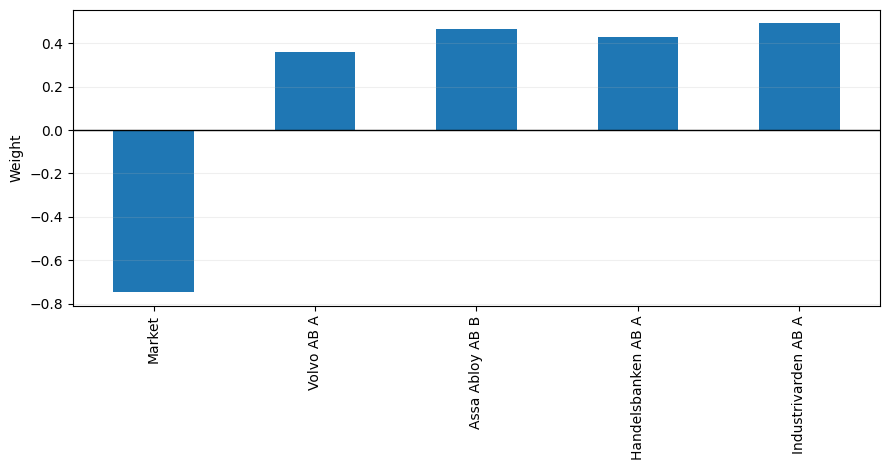

In [62]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

names = ["Volvo AB A", "Assa Abloy AB B", "Handelsbanken AB A", "Industrivarden AB A"]

rets = pd.read_excel("project Stocks_2026.xlsx", sheet_name="return")
f = pd.read_excel("project Factors_2026.xlsx")

# Annualize monthly data (same approach as your code)
f[["rf","rm_rf","smb_vw","hml_vw"]] *= 12
rets.iloc[:,3:] *= 12

f = f.rename(columns={"year":"Year","month":"Month"})
data = rets.merge(f[["Year","Month","rf","rm_rf"]], on=["Year","Month"], how="inner")

Rm = pd.to_numeric(data["rm_rf"], errors="coerce")
Rf = pd.to_numeric(data["rf"], errors="coerce")

mu_Rf = Rf.mean()
mu_Rm_excess = Rm.mean()
var_Rm = Rm.var()

rows = []
for s in names:
    Ri_excess = pd.to_numeric(data[s], errors="coerce") - Rf
    fit = sm.OLS(Ri_excess, sm.add_constant(Rm), missing="drop").fit()

    rows.append({
        "Asset": s,
        "alpha": fit.params.get("const", np.nan),
        "beta": fit.params.get("rm_rf", np.nan),
        "sig2_eps": np.var(fit.resid, ddof=1)
    })

est = pd.DataFrame(rows).set_index("Asset")

# Treynor-Black active sleeve
est["score"] = est["alpha"] / est["sig2_eps"]
est["w_active"] = est["score"] / est["score"].sum()

alpha_A = (est["w_active"] * est["alpha"]).sum()
beta_A  = (est["w_active"] * est["beta"]).sum()
sig2e_A = ((est["w_active"]**2) * est["sig2_eps"]).sum()

# TB mix with market
wA0 = (alpha_A / sig2e_A) / (mu_Rm_excess / var_Rm)
wA_star = wA0 / (1 + (1 - beta_A) * wA0)
wM_star = 1 - wA_star

est["final_weight"] = wA_star * est["w_active"]

weights_table = pd.DataFrame(
    {"Weight": [wM_star] + [est.loc[s, "final_weight"] for s in names]},
    index=["Market"] + names
)

# Realized portfolio series (for realized volatility / realized Sharpe)
asset_returns = data[names].apply(pd.to_numeric, errors="coerce")
realized_port_ret = asset_returns.mul(est["final_weight"], axis=1).sum(axis=1) + wM_star * (Rf + Rm)
realized_port_excess = realized_port_ret - Rf

# Essential portfolio metrics only (one table)
mu_mkt_total = mu_Rf + mu_Rm_excess
sigma_mkt = Rm.std()

alpha_p = (est["final_weight"] * est["alpha"]).sum()
beta_p = wM_star + (est["final_weight"] * est["beta"]).sum()
sig2_eps_p = ((est["final_weight"]**2) * est["sig2_eps"]).sum()

exp_excess_p = alpha_p + beta_p * mu_Rm_excess
exp_total_p = mu_Rf + exp_excess_p
var_p = (beta_p**2) * var_Rm + sig2_eps_p
sigma_p = np.sqrt(var_p)
sharpe_p = exp_excess_p / sigma_p if sigma_p != 0 else np.nan

summary = pd.DataFrame({
    "Metric": [
        "Market weight",
        "Active sleeve weight",
        "Expected portfolio return",
        "Portfolio volatility",
        "Portfolio Sharpe ratio",
        "Portfolio alpha",
        "Portfolio beta",
        "Sum of final weights"
    ],
    "Value": [
        wM_star,
        wA_star,
        exp_total_p,
        sigma_p,
        sharpe_p,
        alpha_p,
        beta_p,
        weights_table["Weight"].sum()
    ]
})

display(summary.style.hide(axis="index").format({"Value": "{:.6f}"}))

# Keep weights output
display(weights_table.style.format({"Weight": "{:.10f}"}))

plt.figure(figsize=(9,4.8))
weights_table["Weight"].plot(kind="bar")
plt.axhline(0, linewidth=1, color="black")
plt.ylabel("Weight")
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()